In [1]:
import pandas as pd
import polars as pl
import seaborn as sns
from pathlib import Path
from tbparse import SummaryReader
base_dir = Path("/Users/morton/VSCode/operators/design/simulation/study-4")
measure = "Accuracies/g"

In [16]:
raw_dfs = []
for condition in ["AL", "PI"]:
    for design in ["0", "1"]:
        reader = SummaryReader(str(base_dir / f"cond-{condition}" / f"design-{design}"))
        raw = (
            pl.DataFrame(reader.scalars)
            .with_columns(run=pl.col("value").cum_count().over(pl.col("step")))
            .with_columns(
                smooth_value=pl.col("value").rolling_mean(window_size=50).over("tag", "run"),
                condition=pl.lit(condition),
                design=pl.lit(design),
            )
        )
        raw_dfs.append(raw)
df = pl.concat(raw_dfs)

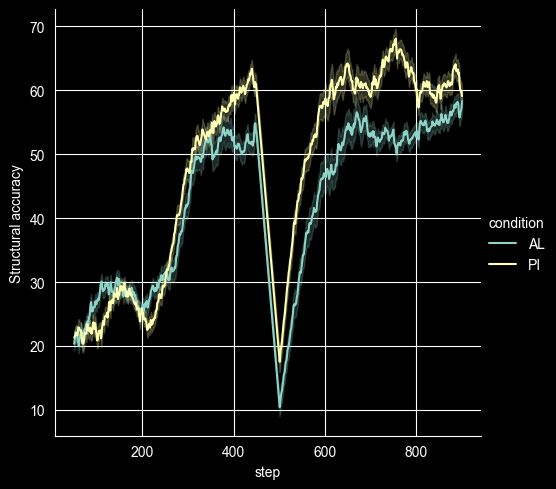

In [17]:
# to_plot = df.query(f'tag == "{measure}"').copy()
# to_plot["value"] = to_plot["value"].rolling(window=10).mean()
g = sns.relplot(
    df.filter(pl.col("tag") == "Accuracies/g"),
    x="step",
    y="smooth_value",
    kind="line",
    hue="condition",
)
g.set(ylabel="Structural accuracy")

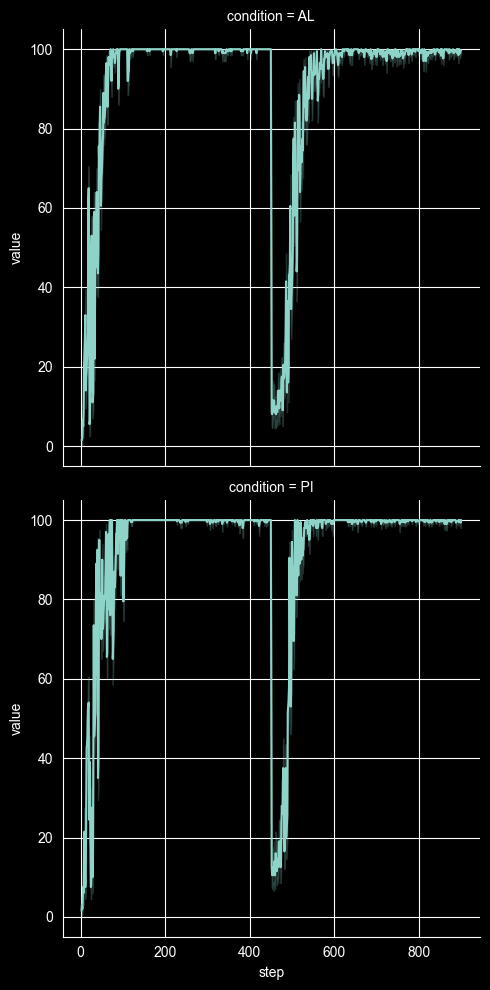

In [17]:
# to_plot = df.query(f'tag == "{measure}"').copy()
# to_plot["value"] = to_plot["value"].rolling(window=10).mean()
sns.relplot(
    df.query(f'tag == "Accuracies/p"'),
    x="step",
    y="value",
    kind="line",
    row="condition",
)